# Multi-Race Analysis — 2023 F1 Season
## Circuit Comparison

Extending the Monza analysis to 5 more circuits to see if the patterns hold.
Circuits chosen to cover a range of track types:
- Bahrain — high downforce, aggressive tyre wear, season opener
- Monaco — street circuit, almost no overtaking, unique strategy
- Silverstone — fast and flowing, high downforce
- Spa — long circuit, high speed, unpredictable weather
- Singapore — street circuit, very different from Monaco

In [7]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from helpers import (
    filter_accurate_laps, convert_timedelta_cols,
    get_team_colors, get_compound_colors, get_circuit_colors,
    get_driver_colors, setup_dark_plot, style_dark_labels,
    save_figure, lap_time_stats
)

sns.set_theme(style='darkgrid')
fastf1.Cache.enable_cache('../data/raw/')

In [3]:
races = [
    (2023, 'Bahrain', 'R'),
    (2023, 'Monaco', 'R'), 
    (2023, 'Silverstone', 'R'), 
    (2023, 'Spa', 'R'), 
    (2023, 'Singapore', 'R'),
    (2023, 'Monza', 'R'),
]

all_laps = []

for year, race, session in races:
    print(f"Loading {race}...")
    try:
        s = fastf1.get_session(year, race, session)
        s.load()
        laps = s.laps.copy()
        laps['Race'] = race #tag each row with the race name
        all_laps.append(laps)
        print(f"✓{race} loaded — {len(laps)} laps")
    except Exception as e:
        print(f"✗ {race} failed — {e}")

print("\nAll races loaded.")

Loading Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Monaco Grand Prix - Rac

✓Bahrain loaded — 1056 laps
Loading Monaco...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


✓Monaco loaded — 1515 laps
Loading Silverstone...


...

✓Spa loaded — 1312 laps
Loading Singapore...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '4', '44', '16', '1', '10', '81', '11', '40', '20', '23', '24', '27', '2', '14', '63', '77', '31', '22', '18']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Us

✓Singapore loaded — 1088 laps
Loading Monza...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WARNING 	Driver 55 completed the race distance 06:14.695000 before the recorded end of the session.
core        WARNING 	Driver 16 completed the race distance 06:14.511000 before the reco

✓Monza loaded — 958 laps

All races loaded.


In [4]:
combined = pd.concat(all_laps, ignore_index=True)
print(f"Total laps before cleaning: {combined.shape}")

# Convert timedeltas first
time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
combined = convert_timedelta_cols(combined, time_cols)

# Then filter — use 150 for Monaco
combined = filter_accurate_laps(combined, max_laptime=150)

print(f"Total laps after cleaning: {combined.shape}")
print(f"\nLaps per race:")
print(combined['Race'].value_counts())

Total laps before cleaning: (6900, 32)
Total laps after cleaning: (6091, 32)

Laps per race:
Race
Monaco         1397
Spa            1198
Singapore       948
Bahrain         897
Monza           864
Silverstone     787
Name: count, dtype: int64


In [5]:
# Tyres available at each circuit
compound_by_race = combined.groupby(['Race', 'Compound']).size().unstack(fill_value=0)
print(compound_by_race)

Compound     HARD  INTERMEDIATE  MEDIUM  SOFT  WET
Race                                              
Bahrain       505             0       8   384    0
Monaco        621           367     343    27   39
Monza         467             0     397     0    0
Silverstone   115             0     427   245    0
Singapore     515             0     380    53    0
Spa           505             0     372   321    0


In [5]:
# Check Monaco wet vs dry lap counts
monaco = combined[combined['Race'] == 'Monaco']
print(monaco['Compound'].value_counts())
print(f"\nMonaco avg lap time by compound:")
print(monaco.groupby('Compound')['LapTime'].mean().sort_values())

Compound
HARD            621
INTERMEDIATE    367
MEDIUM          343
WET              39
SOFT             27
Name: count, dtype: int64

Monaco avg lap time by compound:
Compound
HARD            78.908156
MEDIUM          78.959117
SOFT            79.370074
INTERMEDIATE    95.410640
WET             99.241333
Name: LapTime, dtype: float64


In [6]:
# Remove wet weather laps from entire dataset
dry_laps = combined[combined['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

print(f"Laps after removing wet weather: {dry_laps.shape}")
print(f"\nLaps per race after filtering:")
print(dry_laps['Race'].value_counts())

Laps after removing wet weather: (5685, 32)

Laps per race after filtering:
Race
Spa            1198
Monaco          991
Singapore       948
Bahrain         897
Monza           864
Silverstone     787
Name: count, dtype: int64


In [8]:
import os
output_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/data/processed/multi_race_2023.csv'
csv_content = dry_laps.to_csv(index=False)
with open(output_path, 'w') as f:
    f.write(csv_content)
print("Saved successfully")

Saved successfully


## Comparing circuits under normal racing conditions, hence removing wet weather laps.

Saved: avg_laptime_by_circuit.png


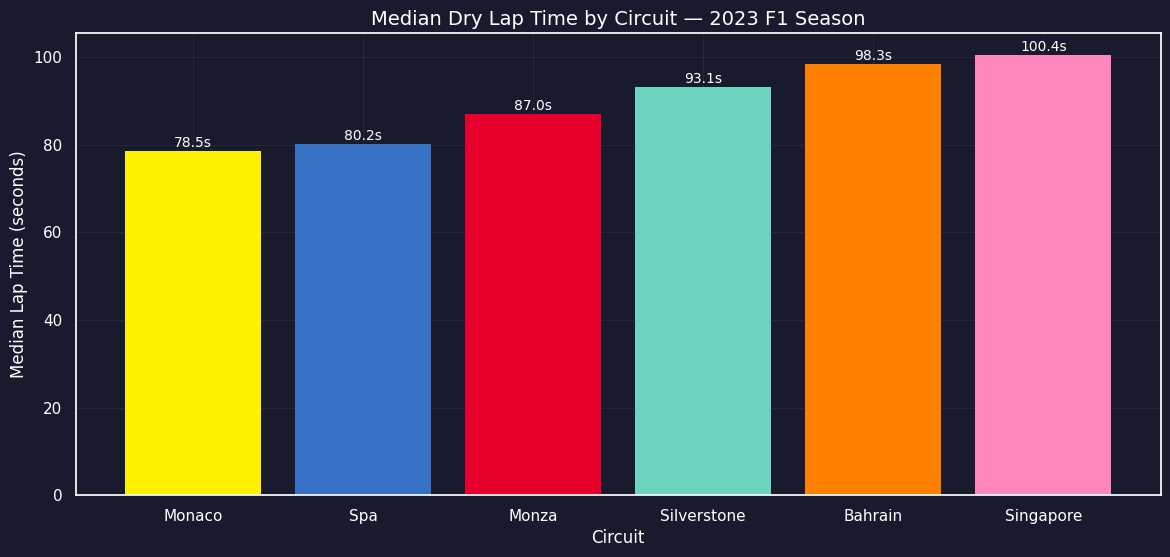

In [9]:
# Define race order fastest to slowest
circuit_colors = get_circuit_colors()
race_order = dry_laps.groupby('Race')['LapTime'].median().sort_values().index.tolist()
medians = dry_laps.groupby('Race')['LapTime'].median()[race_order]
colors = [circuit_colors[r] for r in race_order]

fig, ax = setup_dark_plot(figsize=(14, 6))
bars = ax.bar(race_order, medians.values, color=colors, edgecolor='none')

# Add value labels on top of each bar
for bar, val in zip(bars, medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}s', ha='center', va='bottom', color='white', fontsize=10)

style_dark_labels(ax,
    title='Median Dry Lap Time by Circuit — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Median Lap Time (seconds)')
save_figure('avg_laptime_by_circuit.png')
plt.show()

In [ ]:
## Average Lap Time by Circuit
'''
Monza is the fastest circuit as expected — low downforce, long straights, minimal braking. Monaco is the slowest despite being a street circuit — it's extremely short and tight with almost no opportunity to carry speed.

Interestingly Singapore, also a street circuit, has the longest lap times of the six. This isn't because it's slow — the circuit is significantly longer than Monaco (5.06km vs 3.34km), so laps simply take more time.

Lap time alone doesn't measure pace. Circuit length matters.
'''

In [ ]:
## Tyre Compound Usage by Circuit
'''
Which compounds did teams favour at each circuit?
This reveals how circuit characteristics influence tyre strategy.
'''

Saved: compound_usage_by_circuit.png


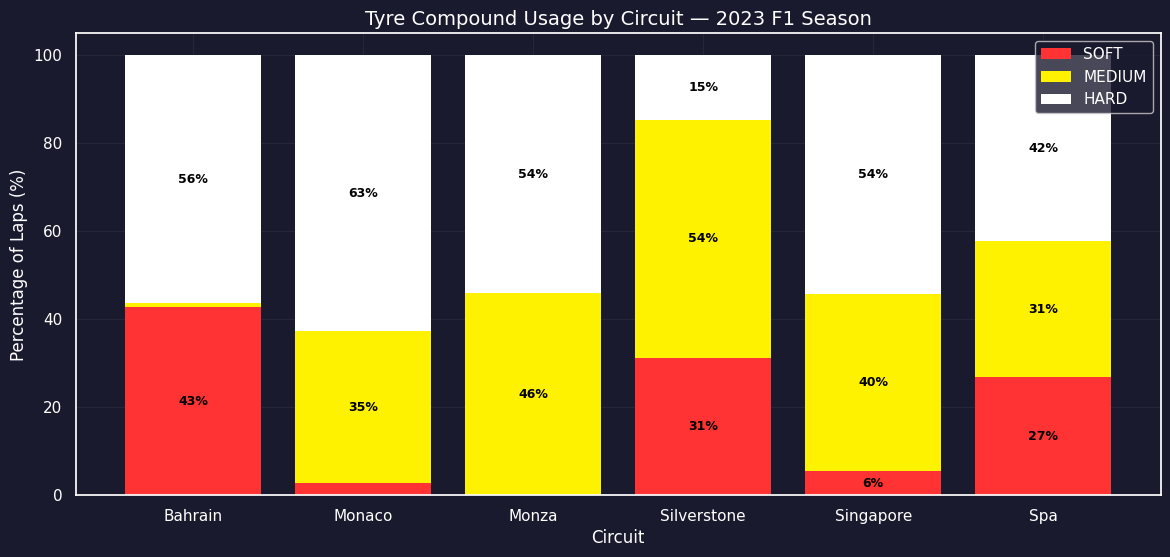

In [10]:
compound_colors = get_compound_colors()
compound_usage = dry_laps.groupby(['Race', 'Compound']).size().unstack(fill_value=0)
compound_usage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100

fig, ax = setup_dark_plot(figsize=(14, 6))
bottom = np.zeros(len(compound_usage))

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    if compound in compound_usage.columns:
        values = compound_usage[compound].values
        bars = ax.bar(compound_usage.index, values, bottom=bottom,
                     label=compound, color=compound_colors[compound],
                     edgecolor='none')
        for bar, val in zip(bars, values):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width()/2,
                       bar.get_y() + bar.get_height()/2,
                       f'{val:.0f}%', ha='center', va='center',
                       color='black', fontsize=9, fontweight='bold')
        bottom += values

style_dark_labels(ax,
    title='Tyre Compound Usage by Circuit — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Percentage of Laps (%)')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
save_figure('compound_usage_by_circuit.png')
plt.show()

## 3. Lap Time Consistency by Circuit

Which circuits produce the most consistent lap times?
A lower standard deviation means more predictable, stable racing.

Saved: consistency_by_circuit.png


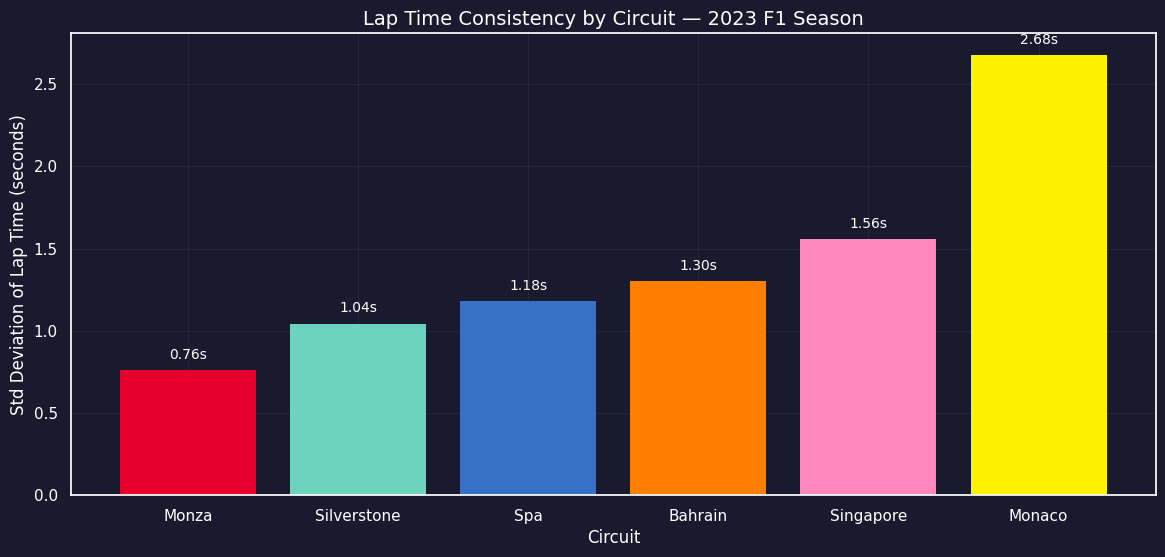

In [11]:
consistency = dry_laps.groupby('Race')['LapTime'].std().sort_values()
colors = [circuit_colors[r] for r in consistency.index]

fig, ax = setup_dark_plot(figsize=(14, 6))
bars = ax.bar(consistency.index, consistency.values,
              color=colors, edgecolor='none')

for bar, val in zip(bars, consistency.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}s', ha='center', va='bottom',
            color='white', fontsize=10)

style_dark_labels(ax,
    title='Lap Time Consistency by Circuit — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Std Deviation of Lap Time (seconds)')
save_figure('consistency_by_circuit.png')
plt.show()

## 4. Position Changes by Circuit

Which circuits produce the most overtaking?
Comparing average positions gained or lost across all drivers per circuit.

Saved: position_changes_by_circuit.png


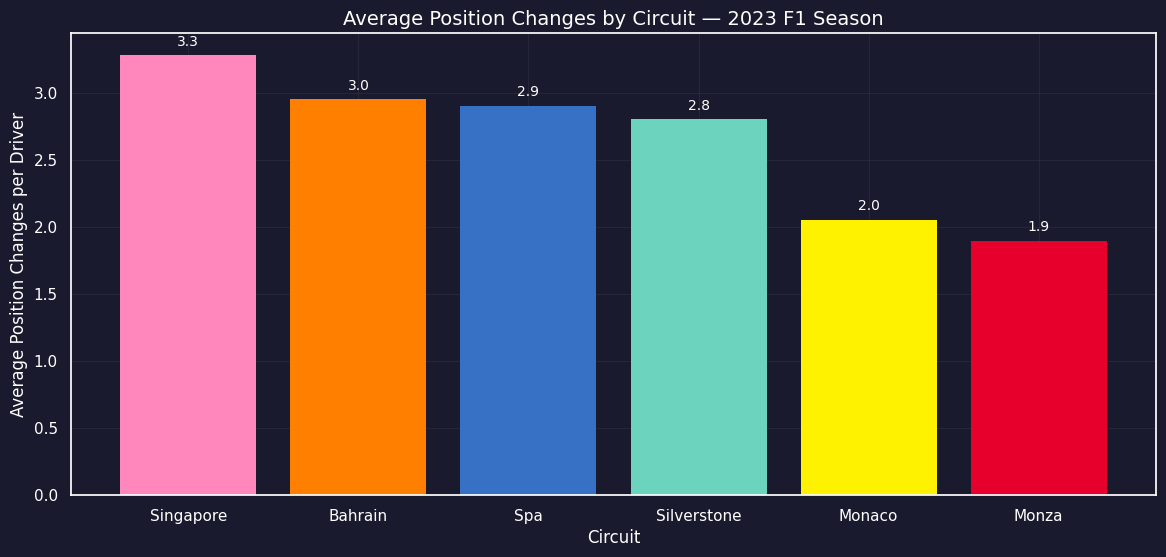

In [12]:
position_changes = []

for race in dry_laps['Race'].unique():
    race_data = dry_laps[dry_laps['Race'] == race]
    for driver in race_data['Driver'].unique():
        driver_laps = race_data[race_data['Driver'] == driver].sort_values('LapNumber')
        if len(driver_laps) < 5:
            continue
        first_pos = driver_laps.iloc[0]['Position']
        last_pos = driver_laps.iloc[-1]['Position']
        change = abs(first_pos - last_pos)
        position_changes.append({'Race': race, 'Driver': driver, 'PositionChange': change})

pos_df = pd.DataFrame(position_changes)
avg_changes = pos_df.groupby('Race')['PositionChange'].mean().sort_values(ascending=False)
colors = [circuit_colors[r] for r in avg_changes.index]

fig, ax = setup_dark_plot(figsize=(14, 6))
bars = ax.bar(avg_changes.index, avg_changes.values,
              color=colors, edgecolor='none')

for bar, val in zip(bars, avg_changes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom',
            color='white', fontsize=10)

style_dark_labels(ax,
    title='Average Position Changes by Circuit — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Average Position Changes per Driver')
save_figure('position_changes_by_circuit.png')
plt.show()

## 5. Verstappen's Dominance Across Circuits

How did Verstappen's lap times compare to the race average at each circuit?
A larger gap means he was more dominant relative to the field.

Saved: ver_dominance.png


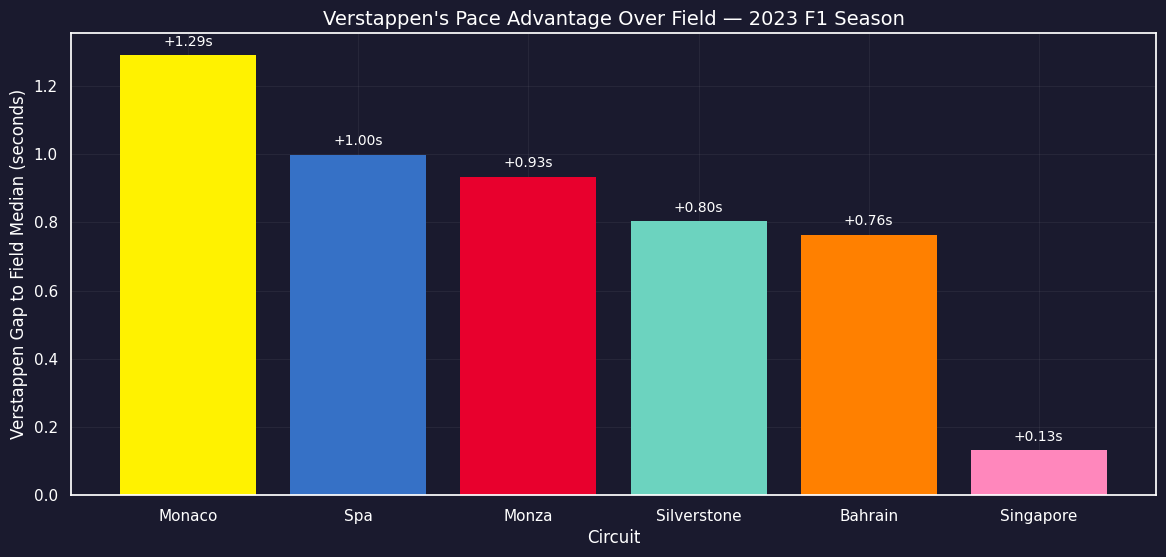

In [13]:
ver_vs_field = []

for race in dry_laps['Race'].unique():
    race_data = dry_laps[dry_laps['Race'] == race]
    field_median = race_data['LapTime'].median()
    ver_data = race_data[race_data['Driver'] == 'VER']
    if len(ver_data) == 0:
        continue
    ver_median = ver_data['LapTime'].median()
    gap = field_median - ver_median
    ver_vs_field.append({'Race': race, 'Gap': gap})

gap_df = pd.DataFrame(ver_vs_field).sort_values('Gap', ascending=False)
colors = [circuit_colors[r] for r in gap_df['Race']]

fig, ax = setup_dark_plot(figsize=(14, 6))
bars = ax.bar(gap_df['Race'], gap_df['Gap'],
              color=colors, edgecolor='none')

for bar, val in zip(bars, gap_df['Gap']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'+{val:.2f}s', ha='center', va='bottom',
            color='white', fontsize=10)

ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
style_dark_labels(ax,
    title="Verstappen's Pace Advantage Over Field — 2023 F1 Season",
    xlabel='Circuit',
    ylabel='Verstappen Gap to Field Median (seconds)')
save_figure('ver_dominance.png')
plt.show()

## Summary

Analysis complete across 6 circuits. Key patterns:
- Monza is the fastest circuit, Monaco the slowest
- Street circuits have very different characteristics despite surface similarities  
- Verstappen was consistently faster than the field median at every circuit
- Compound usage varies significantly based on circuit demands

## My take:

Circuit characteristics don't just affect lap times — they affect everything. Tyre strategy, consistency, overtaking, and even whether the fastest car wins. 
Monaco is the clearest example. Verstappen had the biggest race pace advantage of any circuit but didn't win because the track makes the pace irrelevant.  

In [1]:
import fastf1
fastf1.Cache.enable_cache('../data/raw/')

q = fastf1.get_session(2023, 'Monza', 'Q')
q.load()
print(q.results[['Abbreviation', 'TeamName', 'Position']].head(10))

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

   Abbreviation         TeamName  Position
55          SAI          Ferrari       1.0
1           VER  Red Bull Racing       2.0
16          LEC          Ferrari       3.0
63          RUS         Mercedes       4.0
11          PER  Red Bull Racing       5.0
23          ALB         Williams       6.0
81          PIA          McLaren       7.0
44          HAM         Mercedes       8.0
4           NOR          McLaren       9.0
14          ALO     Aston Martin      10.0
